#  <center>Hurdle Models</center>

**Idea**

- Model rainfall as:
  
    *Probability of rain*
  
    *Amount of rain*
- Exactly matches physical behavior
- Using only May to September data
- Compute Lagged-1 (comparing each day with the previous day) for 'msl', 'sst', 'Qu', 'Qv', 'Qmag'
- Used 7-days moving average

  
**Features**

*Sea Surface Temperature*

*Mean Sea Level Pressure*

*Vertically-integrated Eastward Water Vapour Flux Qu*

*Vertically-integrated Northward Water Vapour Flux Qv*

*Vertically-integrated Moisture Transport*

*Precipitation as target*


**ML version**

- Classifier > P(Rain)
- Regressor > amount | rain
- Combine during inference

##### Libraries

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

##### Data

In [2]:
# Year 2002
jan_apr_2002 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2002\Jan_Apr_2002\data_stream-oper_stepType-instant.nc")
jan_apr_prep_2002 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2002\Jan_Apr_2002\data_stream-oper_stepType-accum.nc")
may_aug_2002 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2002\May_Aug_2002\data_stream-oper_stepType-instant.nc")
may_aug_prep_2002 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2002\May_Aug_2002\data_stream-oper_stepType-accum.nc")
sep_dec_2002 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2002\Sep_Dec_2002\data_stream-oper_stepType-instant.nc")
sep_dec_prep_2002 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2002\Sep_Dec_2002\data_stream-oper_stepType-accum.nc")
# Year 2003
jan_apr_2003 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2003\Jan_Apr_2003\data_stream-oper_stepType-instant.nc")
jan_apr_prep_2003 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2003\Jan_Apr_2003\data_stream-oper_stepType-accum.nc")
may_aug_2003 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2003\May_Aug_2003\data_stream-oper_stepType-instant.nc")
may_aug_prep_2003 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2003\May_Aug_2003\data_stream-oper_stepType-accum.nc")
sep_dec_2003 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2003\Sep_Dec_2003\data_stream-oper_stepType-instant.nc")
sep_dec_prep_2003 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2003\Sep_Dec_2003\data_stream-oper_stepType-accum.nc")
# Year 2004
jan_apr_2004 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2004\Jan_Apr_2004\data_stream-oper_stepType-instant.nc")
jan_apr_prep_2004 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2004\Jan_Apr_2004\data_stream-oper_stepType-accum.nc")
may_aug_2004 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2004\May_Aug_2004\data_stream-oper_stepType-instant.nc")
may_aug_prep_2004 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2004\May_Aug_2004\data_stream-oper_stepType-accum.nc")
sep_dec_2004 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2004\Sep_Dec_2004\data_stream-oper_stepType-instant.nc")
sep_dec_prep_2004 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2004\Sep_Dec_2004\data_stream-oper_stepType-accum.nc")
# Year 2005
jan_apr_2005 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2005\Jan_Apr_2005\data_stream-oper_stepType-instant.nc")
jan_apr_prep_2005 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2005\Jan_Apr_2005\data_stream-oper_stepType-accum.nc")
may_aug_2005 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2005\May_Aug_2005\data_stream-oper_stepType-instant.nc")
may_aug_prep_2005 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2005\May_Aug_2005\data_stream-oper_stepType-accum.nc")
sep_dec_2005 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2005\Sep_Dec_2005\data_stream-oper_stepType-instant.nc")
sep_dec_prep_2005 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2005\Sep_Dec_2005\data_stream-oper_stepType-accum.nc")
# Year 2006
jan_apr_2006 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2006\Jan_Apr_2006\data_stream-oper_stepType-instant.nc")
jan_apr_prep_2006 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2006\Jan_Apr_2006\data_stream-oper_stepType-accum.nc")
may_aug_2006 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2006\May_Aug_2006\data_stream-oper_stepType-instant.nc")
may_aug_prep_2006 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2006\May_Aug_2006\data_stream-oper_stepType-accum.nc")
sep_dec_2006 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2006\Sep_Dec_2006\data_stream-oper_stepType-instant.nc")
sep_dec_prep_2006 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2006\Sep_Dec_2006\data_stream-oper_stepType-accum.nc")
# Year 2007
jan_apr_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\Jan_Apr_2007\data_stream-oper_stepType-instant.nc")
jan_apr_prep_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\Jan_Apr_2007\data_stream-oper_stepType-accum.nc")
may_aug_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\May_Aug_2007\data_stream-oper_stepType-instant.nc")
may_aug_prep_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\May_Aug_2007\data_stream-oper_stepType-accum.nc")
sep_dec_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\Sep_Dec_2007\data_stream-oper_stepType-instant.nc")
sep_dec_prep_2007 = xr.open_dataset(r"D:\Heavy Monsoon\Data\2007\Sep_Dec_2007\data_stream-oper_stepType-accum.nc")

In [3]:
datasets_data = [jan_apr_2002,may_aug_2002,sep_dec_2002,
                 jan_apr_2003,may_aug_2003,sep_dec_2003,
                 jan_apr_2004,may_aug_2004,sep_dec_2004,
                 jan_apr_2005,may_aug_2005,sep_dec_2005,
                 jan_apr_2006,may_aug_2006,sep_dec_2006,
                 jan_apr_2007,may_aug_2007,sep_dec_2007]
datasets_prep = [jan_apr_prep_2002,may_aug_prep_2002,sep_dec_prep_2002,
                 jan_apr_prep_2003,may_aug_prep_2003,sep_dec_prep_2003,
                 jan_apr_prep_2004,may_aug_prep_2004,sep_dec_prep_2004,
                 jan_apr_prep_2005,may_aug_prep_2005,sep_dec_prep_2005,
                 jan_apr_prep_2006,may_aug_prep_2006,sep_dec_prep_2006,
                 jan_apr_prep_2007,may_aug_prep_2007,sep_dec_prep_2007]
# Concatenate along valid_time
all_data = xr.concat(datasets_data, dim="valid_time")
all_prep = xr.concat(datasets_prep, dim="valid_time")

In [4]:
all_data

<xarray.Dataset> Size: 14GB
Dimensions:     (valid_time: 52536, latitude: 121, longitude: 113)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 420kB 2002-01-01 ... 2007-12-31T2...
  * latitude    (latitude) float64 968B 30.0 29.75 29.5 29.25 ... 0.5 0.25 0.0
  * longitude   (longitude) float64 904B 72.0 72.25 72.5 ... 99.5 99.75 100.0
    expver      (valid_time) <U4 841kB '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    t2m         (valid_time, latitude, longitude) float32 3GB 282.7 ... 293.1
    msl         (valid_time, latitude, longitude) float32 3GB 1.02e+05 ... 1....
    sst         (valid_time, latitude, longitude) float32 3GB nan nan ... nan
    viwve       (valid_time, latitude, longitude) float32 3GB 24.31 ... 109.3
    viwvn       (valid_time, latitude, longitude) float32 3GB 8.65 ... -83.71
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-04T20:43 GRIB to CDM+CF via cfgrib-0.9.1...

##### Extract variables

In [5]:
temperature_2m = all_data['t2m']
sea_level_pressure = all_data['msl']
sea_surface_temp = all_data['sst']
Qu = all_data['viwve']
Qv = all_data['viwvn']
precip = all_prep['tp']
# Replace NaN values in sea_surface_temp with t2m values
sst_filled = sea_surface_temp.fillna(temperature_2m)

In [6]:
# Regularize time to hourly grid
full_time = pd.date_range(
    '2002-01-01 00:00:00',
    '2007-12-31 23:00:00',
    freq='h'
)

precip = precip.reindex(valid_time=full_time, method='ffill')
msl = sea_level_pressure.reindex(valid_time=full_time, method='ffill')
sst = sst_filled.reindex(valid_time=full_time, method='ffill')
Qu = Qu.reindex(valid_time=full_time, method='ffill')
Qv = Qv.reindex(valid_time=full_time, method='ffill')

In [7]:
precip_1D = precip.resample(valid_time='1D').sum()
msl_1D = msl.resample(valid_time='1D').mean()
sst_1D = sst.resample(valid_time='1D').mean()
Qu_1D = Qu.resample(valid_time='1D').mean()
Qv_1D = Qv.resample(valid_time='1D').mean()

In [8]:
# Create Daily Dataset
ds_daily = xr.Dataset({
    'tp': precip_1D * 1000,   # mm/day
    'msl': msl_1D,
    'sst': sst_1D,
    'Qu': Qu_1D,
    'Qv': Qv_1D
})

In [9]:
print("NaN Chacked:")
for var in ['tp', 'msl', 'sst', 'Qu', 'Qv']:
    nan_count = ds_daily[var].isnull().sum().item()
    print(f"{var}: {nan_count} NaN values")

NaN Chacked:
tp: 0 NaN values
msl: 0 NaN values
sst: 0 NaN values
Qu: 0 NaN values
Qv: 0 NaN values


In [10]:
# Process each year separately
years = [2002, 2003, 2004, 2005, 2006, 2007]
monsoon_datasets = []
WINDOW = 7
LAG = 1
for year in years:
    # Extract monsoon season for each year
    start_date = f'{year}-05-01'
    end_date = f'{year}-09-30'
    
    # Get daily data for this year's monsoon
    ds_year = ds_daily.sel(valid_time=slice(start_date, end_date))
    
    # Apply weekly smoothing
    ds_year_weekly = xr.Dataset({
        'tp': ds_year['tp'].rolling(valid_time=WINDOW).mean(),
        'msl': ds_year['msl'].rolling(valid_time=WINDOW).mean(),
        'sst': ds_year['sst'].rolling(valid_time=WINDOW).mean(),
        'Qu': ds_year['Qu'].rolling(valid_time=WINDOW).mean(),
        'Qv': ds_year['Qv'].rolling(valid_time=WINDOW).mean()
    })
    
    # Calculate Qmag
    ds_year_weekly['Qmag'] = np.sqrt(ds_year_weekly['Qu']**2 + ds_year_weekly['Qv']**2)
    
    # Add lag features
    for v in ['msl', 'sst', 'Qu', 'Qv', 'Qmag']:
        ds_year_weekly[f'{v}_lag1'] = ds_year_weekly[v].shift(valid_time=LAG)
    
    monsoon_datasets.append(ds_year_weekly)

# Concatenate all years
ds_monsoon_weekly_all = xr.concat(monsoon_datasets, dim='valid_time')
ds_monsoon_weekly_all = ds_monsoon_weekly_all.dropna('valid_time')

In [11]:
print(f"Processed {len(years)} monsoon seasons separately")
print(f"Total monsoon days across all years: {len(ds_monsoon_weekly_all.valid_time)}")

Processed 6 monsoon seasons separately
Total monsoon days across all years: 876


In [12]:
ds_monsoon_weekly_all

<xarray.Dataset> Size: 527MB
Dimensions:     (valid_time: 876, latitude: 121, longitude: 113)
Coordinates:
  * latitude    (latitude) float64 968B 30.0 29.75 29.5 29.25 ... 0.5 0.25 0.0
  * longitude   (longitude) float64 904B 72.0 72.25 72.5 ... 99.5 99.75 100.0
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 7kB 2002-05-08 ... 2007-09-30
Data variables:
    tp          (valid_time, latitude, longitude) float32 48MB 0.1913 ... 7.937
    msl         (valid_time, latitude, longitude) float32 48MB 1.001e+05 ... ...
    sst         (valid_time, latitude, longitude) float32 48MB 307.6 ... 296.8
    Qu          (valid_time, latitude, longitude) float32 48MB 89.46 ... 34.43
    Qv          (valid_time, latitude, longitude) float32 48MB -6.357 ... 27.75
    Qmag        (valid_time, latitude, longitude) float32 48MB 89.68 ... 44.22
    msl_lag1    (valid_time, latitude, longitude) float32 48MB 1.001e+05 ... ...
    sst_lag1    (valid_time, latitude, longitude) float32 48MB 307.4 ... 296.9
    Qu_lag1     (valid_time, latitude, longitude) float32 48MB 87.03 ... 33.77
    Qv_lag1     (valid_time, latitude, longitude) float32 48MB -18.65 ... 20.58
    Qmag_lag1   (valid_time, latitude, longitude) float32 48MB 89.01 ... 39.54

##### Log rainfall & rain occurrence

In [13]:
ds_monsoon_weekly_all['tp_log'] = np.log1p(ds_monsoon_weekly_all['tp'])

RAIN_THRESHOLD = 1.0  # mm/day 
ds_monsoon_weekly_all['rain_occ'] = (ds_monsoon_weekly_all['tp'] > RAIN_THRESHOLD).astype(np.int8)

In [14]:
features = ['msl', 'sst', 'Qu', 'Qv', 'Qmag']
features_lagged = features + [f'{v}_lag1' for v in features]

In [15]:
features_lagged

['msl',
 'sst',
 'Qu',
 'Qv',
 'Qmag',
 'msl_lag1',
 'sst_lag1',
 'Qu_lag1',
 'Qv_lag1',
 'Qmag_lag1']

##### Train / validation split (time-aware)

In [16]:
split_date = np.datetime64('2007-05-01')

train_mask = ds_monsoon_weekly_all.valid_time < split_date
val_mask   = ds_monsoon_weekly_all.valid_time >= split_date

##### Z-score normalization (TRAIN ONLY)
*Compute statistics*

In [17]:
ds_train = ds_monsoon_weekly_all.sel(valid_time=train_mask)

means = {}
stds = {}

for v in features_lagged:
    means[v] = ds_train[v].mean(dim=('valid_time','latitude','longitude'))
    stds[v]  = ds_train[v].std(dim=('valid_time','latitude','longitude'))

*Apply normalization*

In [18]:
ds_norm = ds_monsoon_weekly_all.copy()

for v in features_lagged:
    ds_norm[v] = (ds_monsoon_weekly_all[v] - means[v]) / stds[v]

ds_norm = ds_norm.fillna(0.0)

In [19]:
ds_norm_train = ds_norm.sel(valid_time=train_mask)
ds_norm_val = ds_norm.sel(valid_time=val_mask)

##### Sequence generator (memory-efficient)

In [20]:
# Define sequence length for ConvLSTM
SEQ_LEN = 7
def sequence_generator(ds, features, target, seq_len=7, lead=1, batch_size=8):
    times = ds.valid_time.values
    # times = times[mask]

    n = len(times) - seq_len - lead + 1

    while True:
        idx = np.random.randint(0, n, batch_size)
        Xb, yb = [], []

        for i in idx:
            tX = times[i:i+seq_len]
            ty = times[i + seq_len + lead - 1]

            X = ds[features].sel(valid_time=tX).to_array().values
            X = np.moveaxis(X, 0, -1)   # (time, lat, lon, features)
            y = target.sel(valid_time=ty).values

            Xb.append(X)
            yb.append(y)

        yield np.array(Xb), np.array(yb)

#### ConvLSTM rain-occurrence classifier

In [21]:
classifier = tf.keras.Sequential([
    tf.keras.layers.Input((SEQ_LEN, None, None, len(features_lagged))),
    tf.keras.layers.ConvLSTM2D(16, 3, padding='same',return_sequences=True, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ConvLSTM2D(32, 3, padding='same',return_sequences=True, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ConvLSTM2D(32, 3, padding='same',return_sequences=False, activation='relu'),
    tf.keras.layers.Conv2D(1, kernel_size=1, activation='sigmoid')
])

classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

In [22]:
##### Train classifier
cls_gen = sequence_generator(
    ds_norm_train, features_lagged,
    ds_norm_train['rain_occ'],
    SEQ_LEN
)

In [23]:
with tf.device('/GPU:0'):
    classifier.fit(cls_gen, steps_per_epoch=100, epochs=20)

Epoch 1/20
100/100 [==============================] - 112s 762ms/step - loss: 0.3660 - auc: 0.7819
Epoch 2/20
100/100 [==============================] - 76s 756ms/step - loss: 0.3058 - auc: 0.8580
Epoch 3/20
100/100 [==============================] - 76s 756ms/step - loss: 0.2866 - auc: 0.8779
Epoch 4/20
100/100 [==============================] - 72s 719ms/step - loss: 0.2604 - auc: 0.8990
Epoch 5/20
100/100 [==============================] - 76s 756ms/step - loss: 0.2576 - auc: 0.9062
Epoch 6/20
100/100 [==============================] - 73s 728ms/step - loss: 0.2500 - auc: 0.9112
Epoch 7/20
100/100 [==============================] - 73s 725ms/step - loss: 0.2466 - auc: 0.9164
Epoch 8/20
100/100 [==============================] - 74s 744ms/step - loss: 0.2410 - auc: 0.9224
Epoch 9/20
100/100 [==============================] - 77s 768ms/step - loss: 0.2411 - auc: 0.9218
Epoch 10/20
100/100 [==============================] - 76s 761ms/step - loss: 0.2373 - auc: 0.9266
Epoch 11/20
100/10

##### ConvLSTM rain-amount regressor (rainy weeks only)

In [25]:
reg_mask = train_mask   # time-only mask

In [26]:
regressor = tf.keras.Sequential([
    tf.keras.layers.Input((SEQ_LEN, None, None, len(features_lagged))),

    tf.keras.layers.ConvLSTM2D(
        16, 3, padding='same',
        return_sequences=True,
        activation='relu'
    ),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.ConvLSTM2D(
        32, 3, padding='same',
        return_sequences=True,
        activation='relu'
    ),
    tf.keras.layers.BatchNormalization(),

    # 🔑 LAST ConvLSTM: return_sequences=False
    tf.keras.layers.ConvLSTM2D(
        16, 3, padding='same',
        return_sequences=False,
        activation='relu'
    ),

    tf.keras.layers.Conv2D(1, kernel_size=1, activation='linear')
])
def masked_mse(y_true, y_pred):
    mask = tf.cast(y_true > 0, tf.float32)
    return tf.reduce_sum(mask * tf.square(y_true - y_pred)) / (
        tf.reduce_sum(mask) + 1e-6
    )
regressor.compile(
    optimizer='adam',
    loss=masked_mse
)

In [27]:
##### Train regressor
reg_gen = sequence_generator(
    ds_norm_train, features_lagged,
    ds_norm_train['tp_log'],
    SEQ_LEN
)

In [28]:
with tf.device('/GPU:0'):
    regressor.fit(reg_gen, steps_per_epoch=100, epochs=20)

Epoch 1/20
100/100 [==============================] - 58s 468ms/step - loss: 0.8990
Epoch 2/20
100/100 [==============================] - 46s 457ms/step - loss: 0.4709
Epoch 3/20
100/100 [==============================] - 47s 471ms/step - loss: 0.4114
Epoch 4/20
100/100 [==============================] - 48s 476ms/step - loss: 0.3907
Epoch 5/20
100/100 [==============================] - 47s 467ms/step - loss: 0.3636
Epoch 6/20
100/100 [==============================] - 47s 474ms/step - loss: 0.3488
Epoch 7/20
100/100 [==============================] - 46s 462ms/step - loss: 0.3265
Epoch 8/20
100/100 [==============================] - 46s 462ms/step - loss: 0.3157
Epoch 9/20
100/100 [==============================] - 48s 478ms/step - loss: 0.2998
Epoch 10/20
100/100 [==============================] - 47s 470ms/step - loss: 0.2947
Epoch 11/20
100/100 [==============================] - 47s 472ms/step - loss: 0.2810
Epoch 12/20
100/100 [==============================] - 46s 463ms/step - lo

In [30]:
times = ds_norm.valid_time.values

val_times = times[val_mask.values]
SEQ_LEN = 7

X_seq_val = []
y_val = []
pred_times = []

for t in val_times:
    # index of target time
    ti = np.where(times == t)[0][0]

    # need SEQ_LEN history
    if ti < SEQ_LEN:
        continue

    t_seq = times[ti-SEQ_LEN:ti]

    X = ds_norm[features_lagged].sel(valid_time=t_seq).to_array().values
    X = np.moveaxis(X, 0, -1)   # (time, lat, lon, features)

    y = ds_norm['tp_log'].sel(valid_time=t).values

    X_seq_val.append(X)
    y_val.append(y)
    pred_times.append(t)

X_seq_val = np.array(X_seq_val, dtype=np.float32)
y_val     = np.array(y_val, dtype=np.float32)


In [31]:
log_rain = regressor.predict(X_seq_val)


5/5 [==============================] - 5s 571ms/step


In [71]:
P_rain = classifier.predict(X_seq_val)

5/5 [==============================] - 3s 724ms/step


In [33]:
rain_amt = np.expm1(log_rain)
pred_single = rain_amt
final_rain = P_rain * rain_amt
pred_hybrid = final_rain

In [59]:
times_aligned = np.array(pred_times)
rain_true = (
    ds_monsoon_weekly_all['tp']
    .sel(valid_time=pred_times)
    .values
)
pred_single = pred_single.squeeze()   # (time, lat, lon)
pred_hybrid = pred_hybrid.squeeze()   # (time, lat, lon)
obs_mean = rain_true.mean(axis=(1, 2))
pred_mean_single = pred_single.mean(axis=(1, 2))
pred_mean_hybrid = pred_hybrid.mean(axis=(1, 2))
print(times_aligned.shape)
print(obs_mean.shape)
print(pred_mean_single.shape)
print(pred_mean_hybrid.shape)

(146,)
(146,)
(146,)
(146,)


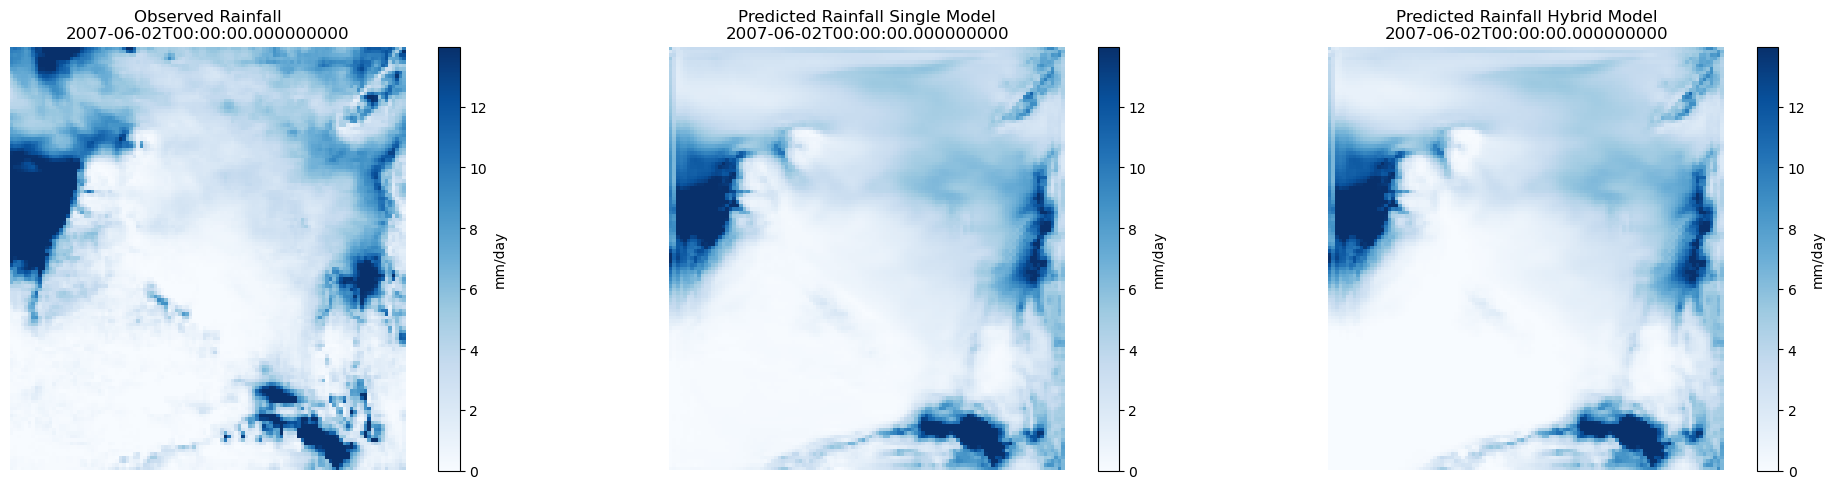

In [39]:
t_idx = 25  # any validation index

obs_map  = rain_true[t_idx]
pred_map_single = pred_single[t_idx]
pred_map_hybrid = pred_hybrid[t_idx]
vmax = np.percentile(obs_map, 95)

plt.figure(figsize=(20, 5))

# Observed
plt.subplot(1, 3, 1)
plt.imshow(obs_map, origin='lower', cmap='Blues', vmin=0, vmax=vmax)
plt.colorbar(label='mm/day')
plt.title(f'Observed Rainfall\n{pred_times[t_idx]}')
plt.axis('off')

# Predicted by Single model
plt.subplot(1, 3, 2)
plt.imshow(pred_map_single, origin='lower', cmap='Blues', vmin=0, vmax=vmax)
plt.colorbar(label='mm/day')
plt.title(f'Predicted Rainfall Single Model\n{pred_times[t_idx]}')
plt.axis('off')

# Predicted by Hybrid models
plt.subplot(1, 3, 3)
plt.imshow(pred_map_hybrid, origin='lower', cmap='Blues', vmin=0, vmax=vmax)
plt.colorbar(label='mm/day')
plt.title(f'Predicted Rainfall Hybrid Model\n{pred_times[t_idx]}')
plt.axis('off')

plt.tight_layout()
plt.show()
